In [39]:
import matplotlib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import *
from scipy.integrate import odeint
from scipy.optimize import fsolve
from math import *
from scipy.integrate import solve_ivp

In [34]:
# On définit les ci:
M = 7
R = 0.20
J = 0.4 * M * (R**2)
coef_frottement_dynamique = 1
coef_frottement_statique = 0.5
g = 9.81

# On définit les fonctions:
phi = 0
thêta = np.pi/2
psi = 0
thêta_point = 0
psi_point = 0
phi_point = -10
xo = 0
yo = 0
zo = 0
xo_point = -.2
yo_point = 0


#on définit les costante d'intégration:
A = thêta_point * sin(psi) - phi_point * sin(thêta) * cos(
    psi) + xo_point * M * R / J
B = thêta_point * cos(psi) + phi_point * sin(thêta) * sin(
    psi) - yo_point * M * R / J
C = psi_point + phi_point * cos(thêta)
#on introduit des constante de calcul:
k = (1 + M * (R**2) / J)
Fo = -M * g * coef_frottement_dynamique# * k
print(A, B, C,k)
#on définit les vitesses de glissements a t=0
Vgxo=xo_point*k-A*R
Vgyo=yo_point*k+B*R


def rhs(x, t):
  Vgx = x[1] * k - A * R
  Vgy = x[3] * k + B * R
  x_pointpoint = (1 / M) * (Fo * k * x[1] + M * g * coef_frottement_dynamique * A * R) / ((Vgx**2 + Vgy**2)**(0.5))
  y_pointpoint = (1 / M) * (Fo * k * x[3] - M * g * coef_frottement_dynamique * B * R) / ((Vgx**2 + Vgy**2)**(0.5))
  #if abs(Vgx) <=Vgxo*(10**(-2)) or abs(Vgy) <=Vgyo*(10**(-2)):
    #return [0, 0, 0, 0]
  #else:
    #return [x[1], x_pointpoint, x[3], y_pointpoint]
  return [x[1], x_pointpoint, x[3], y_pointpoint]

Vgxo,Vgyo

7.5 0.0 -6.123233995736766e-16 3.4999999999999996


(-2.2, 0.0)

In [37]:
TMAX = .06  # durée max de l'intégration exprimée en unité naturelle
N = 500 #nombre de points à calculer
t = np.linspace(0, TMAX, N)  # intervalle de temps d'intégration

CI = [xo, xo_point, yo,
      yo_point]  # condition initiale : hauteur=1, vitesse nulle

traj = odeint(rhs,CI,t)  #on stocke dans la matrice traj[i,j]=y_j(t_i) le resultat de l'integration


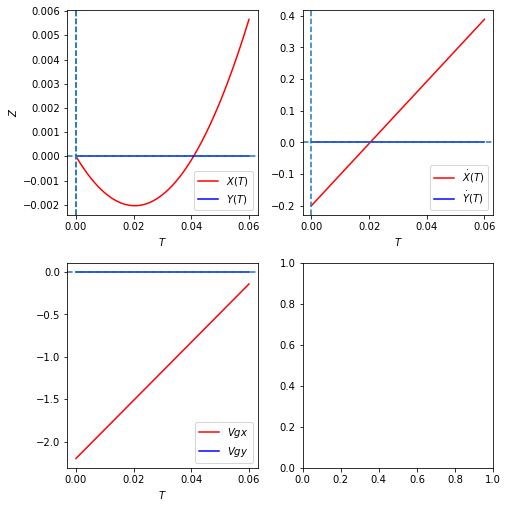

In [38]:
taille_graphe = 1.57 * 2
espace_entre_graphes = .28
hauteur = taille_graphe * (2 + 1 * espace_entre_graphes)
largeur = taille_graphe * (2 + 1 * espace_entre_graphes)
fig = figure(figsize=(largeur, hauteur))
graphe1 = fig.add_subplot(221)
graphe2 = fig.add_subplot(222)
graphe3 = fig.add_subplot(223)
graphe4 = fig.add_subplot(224)

graphe1.plot(t, traj[:, 0], 'r-', label="$X(T)$")
graphe1.plot(t, traj[:, 2], 'b-', label="$Y(T)$")
graphe1.set_xlabel('$T$')
graphe1.set_ylabel('$Z$')
#graphe1.set_xlim([0,2]);graphe1.set_ylim([0,.6])
graphe1.axhline(0, ls='--')
graphe1.axvline(0, ls='--')

graphe2.plot(t, traj[:, 1], 'r-', label='$\dot{X}(T)$')
graphe2.plot(t, traj[:, 3], 'b-', label='$\dot{Y}(T)$')
graphe2.set_xlabel('$T$')

#graphe2.set_xlim([0,2]);graphe2.set_ylim([-1,1.1])
graphe2.axhline(0, ls='--')
graphe2.axvline(0, ls='--')

graphe3.plot(t, traj[:, 1]*k-A*R, 'r-', label="$Vgx$")
graphe3.plot(t, traj[:, 3]*k+B*R, 'b-', label="$Vgy$")
graphe3.set_xlabel('$T$')

#graphe1.set_ylim([-1,1]);
#graphe3.set_ylim([-.5, .5])
graphe3.axhline(0, ls='--')
graphe1.axvline(0, ls='--')

#graphe2.plot(t, (traj[:, 1]*(1-k)+A*R), 'b-', label="$R*wy$")
graphe1.legend()
graphe2.legend()
graphe3.legend()

fig.tight_layout()
plt.show()
#print(traj)


In [ ]:
A,B

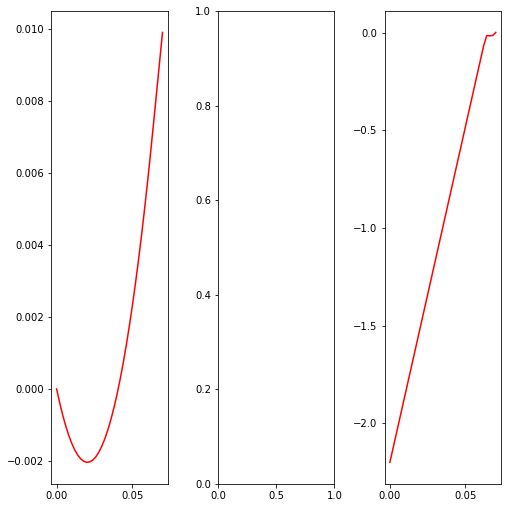

In [46]:
def rhs(t,x):
    Vgx = x[1] * k - A * R
    Vgy = x[3] * k + B * R
    x_pointpoint = (1 / M) * (Fo * k * x[1] + M * g * coef_frottement_dynamique * A * R) / ((Vgx**2 + Vgy**2)**(0.5))
    y_pointpoint = (1 / M) * (Fo * k * x[3] - M * g * coef_frottement_dynamique * B * R) / ((Vgx**2 + Vgy**2)**(0.5))
  #if abs(Vgx) <=Vgxo*(10**(-2)) or abs(Vgy) <=Vgyo*(10**(-2)):
    #return [0, 0, 0, 0]
  #else:
    #return [x[1], x_pointpoint, x[3], y_pointpoint]
    return [x[1], x_pointpoint, x[3], y_pointpoint]



def vitesse_nulle(t, x): 
    """pour éviter des divergences"""
    Vgx = x[1] * k - A * R
    Vgy = x[3] * k + B * R
    Vg=(Vgx**2 + Vgy**2)**(0.5)
    return Vg-1e-2

vitesse_nulle.terminal = True

evenements=[vitesse_nulle]


TMAX=1
t = np.linspace(0, TMAX, N)  # intervalle de temps d'intégration

CI = [xo, xo_point, yo,
      yo_point]  # condition initiale : hauteur=1, vitesse nulle

sol=solve_ivp(rhs,t_span=(0,TMAX),y0=CI,t_eval=t,events=evenements)#,method='DOP853')

fig=figure(figsize=(largeur,hauteur))
graphe1=fig.add_subplot(131)
graphe2=fig.add_subplot(132)
graphe3=fig.add_subplot(133)
    
graphe1.plot(sol.t,sol.y[0],'r-',label="$X(T)$")
graphe3.plot(sol.t,sol.y[1]*k-A*R, 'r-', label="$Vgx$")
#graphe3.plot(t, traj[:, 3]*k+B*R, 'b-', label="$Vgy$")

    
fig.tight_layout()
